# Curate the drive, then train the model

## A multi-log MCAP → LanceDB → full-VLM-training experiment

**Note:** this is for example purposes to demonstrate curation and model training using LanceDB.

**Research question.** Can a quality-filtered, perceptually and semantically deduplicated subset of autonomous-driving images match or beat full-model post-training on every available frame when both runs receive the same optimizer-update budget?

**Populated reference run.** Curated full training reached **0.563 macro F1** versus **0.537** for raw full training. It used 161 instead of 187 unique frames (**14% fewer**), while both runs received 187 optimizer updates and took essentially the same time (95.5 versus 96.2 seconds). Strict JSON compliance improved from **75.8% to 87.9%**. A paired bootstrap over the nine held-out logs gives a 95% interval of **−0.031 to +0.091** for the macro-F1 difference. The vanilla model produced no contract-valid outputs and therefore scored zero under the intentionally strict parser.

This notebook builds compact MCAP logs from the official nuImages mini release, ingests them into one LanceDB table, computes governed feature columns, curates the training split with a LanceDB Feature Engineering UDTF, and fully fine-tunes a 256M open vision-language model directly from LanceDB rows. It compares the vanilla model, full training on all rows, and full training on curated rows.

The task is **driving-scene tagging**, not vehicle control. Ground truth comes from nuImages 2D annotations. The notebook uses all six camera positions represented in the mini release; it does not use LiDAR, radar, CAN state, multi-camera fusion, or temporal model inputs.

The data workflow is platform-neutral. Full training uses PyTorch and runs on Apple Silicon Metal, NVIDIA CUDA on Windows/Linux, or CPU (CPU is supported but intentionally requires an explicit opt-in because it is slow).

## 0. Reproducible local setup

All downloads and generated artifacts stay under this project. The first run downloads a 118 MB public dataset archive, a 45 MB semantic feature extractor, and a roughly 0.5 GB VLM. Expensive results use content-derived fingerprints, so changing the data, prompt, model, curation thresholds, or training configuration invalidates the appropriate cache.

Use Python 3.12. On macOS, the recommended kernel is **Python 3 (lancedb-mcap-demo)** or the project's `.venv`. On Windows, select the interpreter at `.venv\Scripts\python.exe`.

In [1]:
from __future__ import annotations

import importlib.util, subprocess, sys

REQUIRED = {
    "lancedb": "lancedb==0.37.1",
    "geneva": "geneva==0.15.0",
    "mcap": "mcap==1.4.0",
    "pyarrow": "pyarrow>=20",
    "PIL": "pillow>=11",
    "cv2": "opencv-python>=4.10",
    "sklearn": "scikit-learn>=1.6",
    "matplotlib": "matplotlib>=3.9",
    "seaborn": "seaborn>=0.13",
    "tqdm": "tqdm>=4.67",
    "psutil": "psutil>=6",
    "requests": "requests>=2.32",
    "torch": "torch>=2.4",
    "torchvision": "torchvision>=0.19",
    "transformers": "transformers>=5.0,<6",
    "accelerate": "accelerate>=1.2",
}
missing = [dist for module, dist in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages into this kernel:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are installed in:", sys.executable)

All required packages are installed in: /Users/taylor/Documents/GitHub/lancedb-mcap-demo/.venv/bin/python


In [2]:
import gc, hashlib, io, json, os, platform, random, shutil, tarfile, time, warnings
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path.cwd().resolve()
DATA = ROOT / "data"
RAW = DATA / "raw"
NUIMAGES_ROOT = RAW / "nuimages-mini"
MCAP_DIR = DATA / "mcap" / "nuimages-mini"
DB_DIR = DATA / "lancedb-v2"
ARTIFACTS = ROOT / "artifacts-v2"
HF_HOME = ROOT / ".cache" / "huggingface"
TORCH_HOME = ROOT / ".cache" / "torch"
for p in [RAW, NUIMAGES_ROOT, MCAP_DIR, DB_DIR, ARTIFACTS, HF_HOME, TORCH_HOME]:
    p.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(HF_HOME))
os.environ.setdefault("TORCH_HOME", str(TORCH_HOME))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import cv2
import geneva
import lancedb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyarrow as pa
import requests
import seaborn as sns
import torch
import torchvision
import transformers
from IPython.display import Markdown, display
from PIL import Image, ImageOps
from sklearn.metrics import f1_score, precision_recall_fscore_support
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

SEED = 17
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

SOURCE_URL = "https://motional-nuscenes.s3.ap-northeast-1.amazonaws.com/public/nuimages-v1.0/nuimages-v1.0-mini.tgz"
SOURCE_ARCHIVE = RAW / "nuimages-v1.0-mini.tgz"
SOURCE_SHA256 = "9f5da97c9a820785487daea1c0f156ae18ddf2ac7e90245fa6d502b400a732b3"
TABLE_NAME = "nuimages_multicamera"
MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"
MODEL_IMAGE_SIZE = (512, 512)
LEARNING_RATE = 1e-5
VALIDATION_LOSS_EXAMPLES = 12

LABELS = [
    "pedestrian_present", "car_present", "large_vehicle", "two_wheeler",
    "traffic_cone", "barrier", "dense_scene",
]
QUESTION = (
    "Tag this driving-camera image. Return exactly one JSON array and no other text. "
    "Use zero or more of: " + ", ".join(LABELS) + ". "
    "large_vehicle includes trucks, buses, construction vehicles, and trailers; "
    "two_wheeler includes bicycles and motorcycles; dense_scene means at least 12 annotated objects."
)

SEMANTIC_COSINE_THRESHOLD = 0.98
SEMANTIC_DHASH_GUARD = 18
PERCEPTUAL_HAMMING_THRESHOLD = 5

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    MODEL_DTYPE = torch.bfloat16
else:
    DEVICE = torch.device("cpu")
    MODEL_DTYPE = torch.float32

ALLOW_CPU_FULL_TRAINING = os.environ.get("ALLOW_CPU_FULL_TRAINING") == "1"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.titleweight": "bold", "figure.dpi": 120})

hardware = {
    "OS": platform.system(), "architecture": platform.machine(),
    "memory_GB": round(psutil.virtual_memory().total / 2**30),
    "Python": platform.python_version(), "accelerator": str(DEVICE),
    "model_dtype": str(MODEL_DTYPE).replace("torch.", ""),
    "LanceDB": lancedb.__version__, "Feature Engineering": geneva.__version__,
    "PyTorch": torch.__version__, "Transformers": transformers.__version__,
}
display(pd.DataFrame.from_dict(hardware, orient="index", columns=["value"]).rename_axis("environment"))

if DEVICE.type == "cpu" and not ALLOW_CPU_FULL_TRAINING:
    display(Markdown(
        "**CPU detected.** Data preparation, curation, and inspection work normally. "
        "The full-training cells deliberately stop unless `ALLOW_CPU_FULL_TRAINING=1` is set before starting Jupyter. "
        "For a practical full run, use Apple Silicon Metal or an NVIDIA CUDA GPU."
    ))

/Users/taylor/Documents/GitHub/lancedb-mcap-demo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,value
environment,
OS,Darwin
architecture,arm64
memory_GB,48
Python,3.12.13
accelerator,mps
model_dtype,bfloat16
LanceDB,0.37.1
Feature Engineering,0.15.0
PyTorch,2.13.0


## 1. From public driving data to independent MCAP logs

MCAP is a log container for timestamped robotics messages. This version uses the official nuImages mini archive: 50 annotated samples from 44 separate driving logs in Boston and Singapore.

nuImages distributes annotated keyframes plus nearby unannotated sweeps. We normalize each sample into a compact MCAP containing the annotated camera frame and three neighboring frames on either side. The keyframe labels are propagated only within ±1.5 seconds, and every row records that temporal distance. Splits are assigned by complete driving log, never by adjacent frame.

In [19]:
def sha256_file(path: Path, chunk_size: int = 2**20) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def download(url: str, path: Path, expected_sha256: str):
    if path.exists() and sha256_file(path) == expected_sha256:
        print(f"Cache hit: {path.name}"); return
    if path.exists():
        path.unlink()
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        with open(path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc="Download nuImages mini") as bar:
            for chunk in response.iter_content(2**20):
                if chunk: f.write(chunk); bar.update(len(chunk))
    actual = sha256_file(path)
    if actual != expected_sha256:
        raise RuntimeError(f"Source checksum mismatch: expected {expected_sha256}, got {actual}")

def safe_extract_tgz(archive: Path, destination: Path):
    marker = destination / "v1.0-mini" / "sample.json"
    if marker.exists():
        print("Cache hit: extracted nuImages mini"); return
    destination.mkdir(parents=True, exist_ok=True)
    root = destination.resolve()
    with tarfile.open(archive, "r:gz") as tar:
        for member in tar.getmembers():
            target = (destination / member.name).resolve()
            if target != root and root not in target.parents:
                raise RuntimeError(f"Unsafe archive member: {member.name}")
        tar.extractall(destination)

download(SOURCE_URL, SOURCE_ARCHIVE, SOURCE_SHA256)
safe_extract_tgz(SOURCE_ARCHIVE, NUIMAGES_ROOT)
print({"archive_MB": round(SOURCE_ARCHIVE.stat().st_size / 1e6, 1), "sha256": SOURCE_SHA256})

Cache hit: nuimages-v1.0-mini.tgz
Cache hit: extracted nuImages mini
{'archive_MB': 117.9, 'sha256': '9f5da97c9a820785487daea1c0f156ae18ddf2ac7e90245fa6d502b400a732b3'}


In [4]:
META = NUIMAGES_ROOT / "v1.0-mini"
load_json = lambda name: json.loads((META / name).read_text())
samples = load_json("sample.json")
sample_data = {x["token"]: x for x in load_json("sample_data.json")}
logs = {x["token"]: x for x in load_json("log.json")}
categories = {x["token"]: x["name"] for x in load_json("category.json")}
sensors = {x["token"]: x for x in load_json("sensor.json")}
calibrated = {x["token"]: x for x in load_json("calibrated_sensor.json")}

objects_by_keyframe = defaultdict(list)
for ann in load_json("object_ann.json"):
    objects_by_keyframe[ann["sample_data_token"]].append(categories[ann["category_token"]])

def label_record(category_names):
    counts = Counter(category_names)
    object_count = sum(counts.values())
    flags = {
        "pedestrian_present": sum(v for k, v in counts.items() if k.startswith("human.pedestrian")) >= 1,
        "car_present": counts["vehicle.car"] >= 1,
        "large_vehicle": sum(counts[k] for k in ["vehicle.truck", "vehicle.bus.rigid", "vehicle.construction", "vehicle.trailer"]) >= 1,
        "two_wheeler": counts["vehicle.bicycle"] + counts["vehicle.motorcycle"] >= 1,
        "traffic_cone": counts["movable_object.trafficcone"] >= 1,
        "barrier": counts["movable_object.barrier"] >= 1,
        "dense_scene": object_count >= 12,
    }
    return [x for x in LABELS if flags[x]], object_count, dict(counts)

sample_labels, label_matrix, groups = {}, [], []
for sample in samples:
    labels, object_count, category_counts = label_record(objects_by_keyframe[sample["key_camera_token"]])
    sample_labels[sample["token"]] = {"labels": labels, "object_count": object_count, "category_counts": category_counts}
    label_matrix.append([int(x in labels) for x in LABELS]); groups.append(sample["log_token"])
label_matrix, groups = np.asarray(label_matrix), np.asarray(groups)

# Deterministic group-aware split search: all frames from a log remain together.
indices, overall_rate, best = np.arange(len(samples)), label_matrix.mean(axis=0), None
for candidate_seed in range(300):
    trainval, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=.20, random_state=candidate_seed).split(indices, groups=groups))
    train_rel, val_rel = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=candidate_seed + 1000).split(trainval, groups=groups[trainval]))
    train_idx, val_idx = trainval[train_rel], trainval[val_rel]
    parts = [train_idx, val_idx, test_idx]
    missing = sum(np.any(label_matrix[p].sum(axis=0) == 0) for p in parts)
    score = missing * 100 + sum(np.abs(label_matrix[p].mean(axis=0) - overall_rate).mean() for p in parts)
    if best is None or score < best[0]: best = (score, candidate_seed, *parts)

_, split_seed, train_idx, val_idx, test_idx = best
sample_split = {}
for split, part in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
    sample_split.update({samples[i]["token"]: split for i in part})

split_summary = []
for split in ["train", "validation", "test"]:
    chosen = [i for i, s in enumerate(samples) if sample_split[s["token"]] == split]
    split_summary.append({"split": split, "annotated_samples": len(chosen), "independent_logs": len(set(groups[chosen])),
                          **{label: int(label_matrix[chosen, j].sum()) for j, label in enumerate(LABELS)}})
display(pd.DataFrame(split_summary))
print(f"Selected deterministic group-stratification seed: {split_seed}")

,split,annotated_samples,independent_logs,pedestrian_present,car_present,large_vehicle,two_wheeler,traffic_cone,barrier,dense_scene
0,train,28,26,17,20,12,11,8,8,9
1,validation,12,9,7,8,5,4,4,3,3
2,test,10,9,6,8,6,4,2,2,3


Selected deterministic group-stratification seed: 71


In [5]:
from mcap.writer import Writer

ANNOTATION_SCHEMA = {
    "type": "object",
    "properties": {
        "sample_id": {"type": "string"}, "log_id": {"type": "string"},
        "split": {"type": "string"}, "camera_channel": {"type": "string"},
        "labels": {"type": "array", "items": {"type": "string"}},
        "object_count": {"type": "integer"}, "category_counts": {"type": "object"},
    },
}

def sample_chain(sample):
    key = sample_data[sample["key_camera_token"]]
    current = key
    while current["prev"]:
        current = sample_data[current["prev"]]
    chain = []
    while current:
        if abs(current["timestamp"] - sample["timestamp"]) <= 1_500_000:
            chain.append(current)
        current = sample_data[current["next"]] if current["next"] else None
    return chain

conversion_spec = {
    "source_sha256": SOURCE_SHA256, "window_us": 1_500_000,
    "split_seed": split_seed, "labels": LABELS,
}
conversion_fingerprint = hashlib.sha256(json.dumps(conversion_spec, sort_keys=True).encode()).hexdigest()
conversion_manifest = MCAP_DIR / "manifest.json"

cache_ok = False
if conversion_manifest.exists():
    old = json.loads(conversion_manifest.read_text())
    cache_ok = old.get("fingerprint") == conversion_fingerprint and len(list(MCAP_DIR.glob("*.mcap"))) == len(samples)

if cache_ok:
    print(f"Cache hit: {len(samples)} compact MCAP logs")
else:
    for old_mcap in MCAP_DIR.glob("*.mcap"):
        old_mcap.unlink()
    for sample in tqdm(samples, desc="Write compact MCAP logs"):
        key = sample_data[sample["key_camera_token"]]
        sensor = sensors[calibrated[key["calibrated_sensor_token"]]["sensor_token"]]
        channel_name = sensor["channel"]
        label_info = sample_labels[sample["token"]]
        payload = {
            "sample_id": sample["token"], "log_id": sample["log_token"],
            "split": sample_split[sample["token"]], "camera_channel": channel_name,
            **label_info,
        }
        path = MCAP_DIR / f"nuimages-mini-{sample['token'][:12]}.mcap"
        with open(path, "wb") as f:
            writer = Writer(f)
            writer.start(profile="nuimages-mini", library="lancedb-mcap-demo")
            annotation_schema_id = writer.register_schema("driving_scene_labels", "jsonschema", json.dumps(ANNOTATION_SCHEMA).encode())
            image_channel = writer.register_channel(f"/camera/{channel_name}/image_jpeg", "jpeg", 0,
                                                    {"camera_channel": channel_name})
            annotation_channel = writer.register_channel("/annotations/scene_labels", "json", annotation_schema_id)
            writer.add_metadata("source", {"dataset": "nuImages mini", "sample_id": sample["token"],
                                            "log_id": sample["log_token"], "location": logs[sample["log_token"]]["location"]})
            writer.add_message(annotation_channel, sample["timestamp"] * 1000, json.dumps(payload, sort_keys=True).encode(), sample["timestamp"] * 1000)
            for sequence, frame in enumerate(sample_chain(sample)):
                image_bytes = (NUIMAGES_ROOT / frame["filename"]).read_bytes()
                writer.add_message(image_channel, frame["timestamp"] * 1000, image_bytes, frame["timestamp"] * 1000, sequence=sequence)
            writer.finish()
    conversion_manifest.write_text(json.dumps({"fingerprint": conversion_fingerprint, "files": len(samples)}, indent=2))

print({"MCAP_files": len(list(MCAP_DIR.glob('*.mcap'))),
       "total_MB": round(sum(p.stat().st_size for p in MCAP_DIR.glob('*.mcap')) / 1e6, 1)})

Cache hit: 50 compact MCAP logs
{'MCAP_files': 50, 'total_MB': 61.2}


## 2. One multimodal Lance table

Lance is the open-source columnar format underneath this workflow. It keeps large image blobs beside typed metadata while supporting scans, random row access, and versioned updates. LanceDB OSS is the in-process database and query layer: filters and vector search operate over the same table.

The compact MCAP collection is now the immutable robotics-log input. We inspect its channels, pair every image with the keyframe annotation in that MCAP, and write the images, provenance, split, and targets into one Lance table. Labels on sweep frames are intentionally marked as propagated and include `label_age_ms`.

In [6]:
from mcap.reader import make_reader

topic_counts, schema_counts, rows = Counter(), Counter(), []
for mcap_path in tqdm(sorted(MCAP_DIR.glob("*.mcap")), desc="Read MCAP logs"):
    images, annotation = [], None
    with open(mcap_path, "rb") as f:
        reader = make_reader(f)
        for schema, channel, message in reader.iter_messages():
            topic_counts[channel.topic] += 1
            schema_counts[(schema.name if schema else "schema-less", channel.message_encoding)] += 1
            if channel.message_encoding == "jpeg":
                images.append((message.log_time, bytes(message.data)))
            elif channel.topic == "/annotations/scene_labels":
                annotation = (message.log_time, json.loads(message.data))
    if annotation is None:
        raise RuntimeError(f"Missing annotation message in {mcap_path.name}")
    annotation_time, info = annotation
    for timestamp_ns, image_bytes in images:
        with Image.open(io.BytesIO(image_bytes)) as image:
            width, height = image.size
        rows.append({
            "frame_id": f"{info['sample_id']}-{timestamp_ns}",
            "sample_id": info["sample_id"], "log_id": info["log_id"],
            "location": logs[info["log_id"]]["location"], "camera_channel": info["camera_channel"],
            "split": info["split"], "timestamp_ns": timestamp_ns,
            "time_offset_s": (timestamp_ns - annotation_time) / 1e9,
            "is_key_frame": timestamp_ns == annotation_time,
            "label_age_ms": abs(timestamp_ns - annotation_time) / 1e6,
            "image": image_bytes, "image_format": "jpeg", "width": width, "height": height,
            "object_count_gt": info["object_count"], "labels": info["labels"],
            "label_text": json.dumps(info["labels"], separators=(",", ":")),
            "source_mcap": mcap_path.name, "source_uri": SOURCE_URL,
        })

display(pd.DataFrame(topic_counts.most_common(10), columns=["topic", "messages"]))
display(pd.DataFrame([(a, b, n) for (a, b), n in schema_counts.items()], columns=["schema", "encoding", "messages"]))
print(f"Prepared {len(rows)} frames from {len(set(r['sample_id'] for r in rows))} samples and {len(set(r['log_id'] for r in rows))} independent logs.")

Read MCAP logs: 100%|██████████| 50/50 [00:00<00:00, 869.35it/s]


,topic,messages
0,/camera/CAM_BACK/image_jpeg,70
1,/camera/CAM_BACK_LEFT/image_jpeg,67
2,/camera/CAM_BACK_RIGHT/image_jpeg,61
3,/camera/CAM_FRONT/image_jpeg,54
4,/annotations/scene_labels,50
5,/camera/CAM_FRONT_RIGHT/image_jpeg,49
6,/camera/CAM_FRONT_LEFT/image_jpeg,35


,schema,encoding,messages
0,schema-less,jpeg,336
1,driving_scene_labels,json,50


Prepared 336 frames from 50 samples and 44 independent logs.


In [7]:
schema = pa.schema([
    pa.field("frame_id", pa.string()), pa.field("sample_id", pa.string()), pa.field("log_id", pa.string()),
    pa.field("location", pa.string()), pa.field("camera_channel", pa.string()), pa.field("split", pa.string()),
    pa.field("timestamp_ns", pa.int64()), pa.field("time_offset_s", pa.float64()),
    pa.field("is_key_frame", pa.bool_()), pa.field("label_age_ms", pa.float64()),
    pa.field("image", pa.large_binary()), pa.field("image_format", pa.string()),
    pa.field("width", pa.int32()), pa.field("height", pa.int32()),
    pa.field("object_count_gt", pa.int64()), pa.field("labels", pa.list_(pa.string())),
    pa.field("label_text", pa.string()), pa.field("source_mcap", pa.string()), pa.field("source_uri", pa.string()),
])

db = geneva.connect(DB_DIR)
table = db.create_table(TABLE_NAME, pa.Table.from_pylist(rows, schema=schema), mode="overwrite")
print(table.schema)
print(f"Rows: {table.count_rows()} · Lance version: {table.version}")

preview = (table.search().where("is_key_frame = true").select([
    "frame_id", "log_id", "location", "camera_channel", "split", "labels", "object_count_gt"
]).limit(8).to_arrow().to_pandas())
display(preview)

frame_id: string
sample_id: string
log_id: string
location: string
camera_channel: string
split: string
timestamp_ns: int64
time_offset_s: double
is_key_frame: bool
label_age_ms: double
image: large_binary
image_format: string
width: int32
height: int32
object_count_gt: int64
labels: list<item: string>
  child 0, item: string
label_text: string
source_mcap: string
source_uri: string
Rows: 336 · Lance version: 137


,frame_id,log_id,location,camera_channel,split,labels,object_count_gt
0,09acd654cb514bdeab8e3afedad74fca-1535352274870...,4ed5d1230fcb48d39db895f754e724f9,singapore-onenorth,CAM_FRONT_RIGHT,train,"[pedestrian_present, car_present, large_vehicl...",16
1,09b7a70c10d94446b6932f894caf0a9e-1535342963787...,e3e0dc593b614a49a854e048576619c1,singapore-onenorth,CAM_BACK,test,"[pedestrian_present, car_present, large_vehicl...",4
2,0b38985d779b4fcd94cf846006c93bed-1535514187537...,93f5da376907439482daa866a5363c20,singapore-onenorth,CAM_BACK,train,"[pedestrian_present, car_present, two_wheeler,...",7
3,0b8de86ffe9740ddb3d50b5a474bc7c3-1527712679297...,bf25bfdf8064437f847bc1c298e0a202,boston-seaport,CAM_BACK_LEFT,test,"[car_present, large_vehicle, traffic_cone]",11
4,0c04ea170e834a75a98218df768f33de-1530847097147...,38b69527a4c54f88a4a3e40513db4d0b,singapore-onenorth,CAM_BACK_LEFT,test,[two_wheeler],1
5,0deae1f926c148378bbd871055df8b08-1515035386214...,47a3cdb2b8ef458fb5d7d59485256573,singapore-onenorth,CAM_FRONT_RIGHT,validation,"[pedestrian_present, car_present, large_vehicl...",34
6,0e27f6e0a9734a54a7dc73bce00438e9-1528978813270...,92916188d49a4c12a86bd0fefc034626,singapore-onenorth,CAM_FRONT_RIGHT,validation,[car_present],1
7,0ec9c7eb27cc48b298d1d5ea72bbaafd-1533113758512...,583057fc827947f6b7860204fb3e2d35,singapore-onenorth,CAM_FRONT,validation,"[two_wheeler, traffic_cone]",11


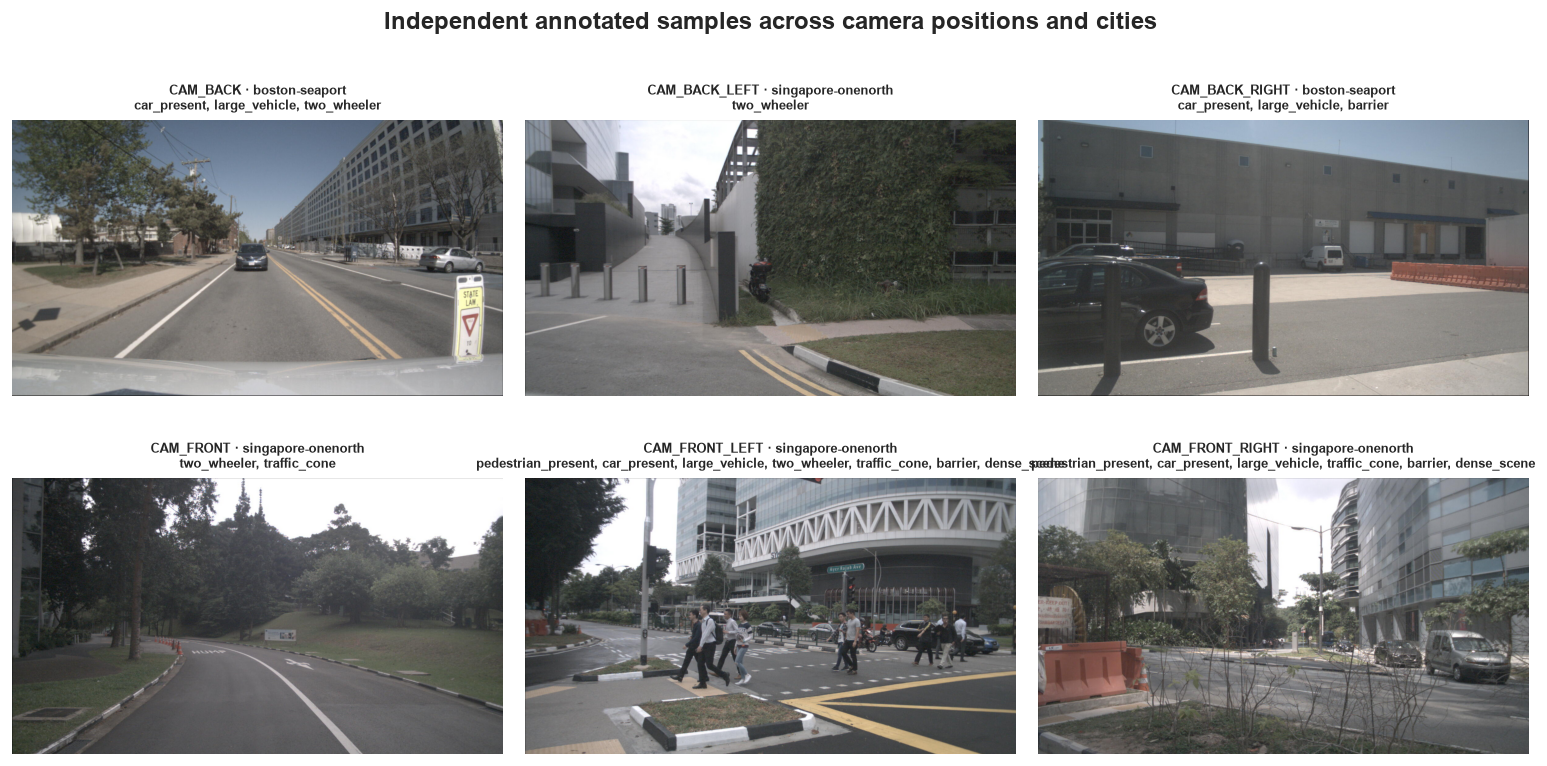

In [8]:
def show_rows(records, title):
    records = list(records)
    ncols, nrows = 3, int(np.ceil(len(records) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows))
    for ax, row in zip(np.asarray(axes).reshape(-1), records):
        ax.imshow(Image.open(io.BytesIO(row["image"])))
        ax.set_title(f"{row['camera_channel']} · {row['location']}\n" + ", ".join(row["labels"]), fontsize=8)
        ax.axis("off")
    for ax in np.asarray(axes).reshape(-1)[len(records):]: ax.axis("off")
    plt.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()

keyframes = table.search().where("is_key_frame = true").select([
    "image", "camera_channel", "location", "labels"
]).to_arrow().to_pylist()
sample_rows = []
for index, camera in enumerate(sorted(set(r["camera_channel"] for r in keyframes))):
    candidates = [r for r in keyframes if r["camera_channel"] == camera]
    preferred_city = "boston-seaport" if index % 2 == 0 else "singapore-onenorth"
    sample_rows.append(next((r for r in candidates if r["location"] == preferred_city), candidates[0]))
show_rows(sample_rows, "Independent annotated samples across camera positions and cities")

## 3. Compute model-ready and semantic columns on the data

LanceDB Feature Engineering, currently available through the `geneva` Python package, lets us declare versioned transforms and backfill their results into the table. We store both the source JPEG and a deterministic 512×512 letterboxed JPEG column. Keeping the model representation in Lance costs additional table storage, but removes the loose-file export and makes preprocessing versioned and queryable.

Brightness, blur, dHash, and an ImageNet-trained ResNet-18 embedding are also table columns. dHash captures almost-identical pixels; the normalized 512-dimensional representation adds semantic structure. The ResNet model is an intentionally modest feature extractor—not a claim that ImageNet semantics perfectly represent driving scenes.

In [9]:
@geneva.udf(data_type=pa.large_binary(), version="model-jpeg-letterbox-512-v1")
def model_image(image: bytes) -> bytes:
    from PIL import Image, ImageOps
    import io
    with Image.open(io.BytesIO(image)) as im:
        prepared = ImageOps.pad(im.convert("RGB"), (512, 512), method=Image.Resampling.LANCZOS, color=(0, 0, 0))
        out = io.BytesIO(); prepared.save(out, format="JPEG", quality=92)
        return out.getvalue()

@geneva.udf(data_type=pa.float32(), version="brightness-v2")
def brightness(model_image: bytes) -> float:
    import cv2, numpy as np
    arr = cv2.imdecode(np.frombuffer(model_image, np.uint8), cv2.IMREAD_GRAYSCALE)
    if arr is None: raise ValueError("JPEG decode failed")
    return float(arr.mean())

@geneva.udf(data_type=pa.float32(), version="blur-score-v2")
def blur_score(model_image: bytes) -> float:
    import cv2, numpy as np
    arr = cv2.imdecode(np.frombuffer(model_image, np.uint8), cv2.IMREAD_GRAYSCALE)
    if arr is None: raise ValueError("JPEG decode failed")
    return float(cv2.Laplacian(arr, cv2.CV_64F).var())

@geneva.udf(data_type=pa.list_(pa.float32(), 64), version="dhash64-v2")
def dhash_embedding(model_image: bytes) -> list[float]:
    import cv2, numpy as np
    arr = cv2.imdecode(np.frombuffer(model_image, np.uint8), cv2.IMREAD_GRAYSCALE)
    if arr is None: raise ValueError("JPEG decode failed")
    small = cv2.resize(arr, (9, 8), interpolation=cv2.INTER_AREA)
    return (small[:, 1:] > small[:, :-1]).astype(np.float32).reshape(-1).tolist()

_SEMANTIC_RUNTIME = {}
@geneva.udf(data_type=pa.list_(pa.float32(), 512), version="resnet18-semantic-v1", num_cpus=1)
def semantic_embedding(model_image: bytes) -> list[float]:
    import io, torch
    from PIL import Image
    from torchvision.models import resnet18, ResNet18_Weights
    global _SEMANTIC_RUNTIME
    if not _SEMANTIC_RUNTIME:
        torch.set_num_threads(1)
        weights = ResNet18_Weights.DEFAULT
        network = resnet18(weights=weights)
        network.fc = torch.nn.Identity(); network.eval()
        _SEMANTIC_RUNTIME = {"model": network, "transform": weights.transforms()}
    with Image.open(io.BytesIO(model_image)) as im, torch.inference_mode():
        vector = _SEMANTIC_RUNTIME["model"](_SEMANTIC_RUNTIME["transform"](im.convert("RGB")).unsqueeze(0))[0]
        vector = torch.nn.functional.normalize(vector, dim=0)
    return vector.cpu().float().tolist()

# Prewarm the small public weight file once; Feature Engineering workers reuse TORCH_HOME.
from torchvision.models import ResNet18_Weights
ResNet18_Weights.DEFAULT.get_state_dict(progress=True)

feature_udfs = [
    ("model_image", model_image), ("brightness", brightness), ("blur_score", blur_score),
    ("dhash_embedding", dhash_embedding), ("semantic_embedding", semantic_embedding),
]
feature_backend = "LanceDB Feature Engineering UDF backfill"
try:
    with db.local_ray_context():
        for name, fn in feature_udfs:
            if name not in table.schema.names:
                table.add_columns({name: fn})
            if table.search().where(f"{name} IS NULL").limit(1).to_arrow().num_rows:
                print(f"Backfilling {name} …")
                table.backfill(name, concurrency=1, checkpoint_size=32, _admission_check=False)
except Exception as exc:
    feature_backend = f"same UDFs, in-process executor fallback ({type(exc).__name__})"
    warnings.warn(f"Feature Engineering worker executor unavailable; executing the declared UDFs locally: {exc}")
    current = table.to_arrow().to_pylist()
    for name, fn in feature_udfs:
        if name in table.schema.names:
            table.drop_columns([name])
        sql_type = dict(model_image="large_binary", brightness="float", blur_score="float",
                        dhash_embedding="fixed_size_list(float, 64)",
                        semantic_embedding="fixed_size_list(float, 512)")[name]
        table.add_columns({name: f"cast(null as {sql_type})"})
        updates = [{"frame_id": row["frame_id"], name: fn.func(row["model_image"] if name != "model_image" else row["image"])} for row in tqdm(current, desc=name)]
        table.merge_insert("frame_id").when_matched_update_all().execute(pa.Table.from_pylist(updates))
        current = table.to_arrow().to_pylist()

print("Feature backend:", feature_backend)
print(f"Lance version after features: {table.version}")
display(table.search().select(["frame_id", "brightness", "blur_score", "semantic_embedding"]).limit(3).to_arrow().to_pandas())

2026-08-25 08:58:51,990	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Initializing Ray cluster. This could take a few minutes, especially if there are lots of dependencies to install.
2026-08-25 08:58:56,151	INFO worker.py:2015 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
/Users/taylor/Documents/GitHub/lancedb-mcap-demo/.venv/lib/python3.12/site-packages/geneva/table.py:1945: UserWarning: Could not validate type for column 'image' (parameter 'image') in UDF 'model_image' with annotation <class 'bytes'>. Type validation skipped for this column.
  self._validate_udf_input_columns(udf, input_columns)
/Users/taylor/Documents/GitHub/lancedb-mcap-demo/.venv/lib/python3.12/site-packages/geneva/table.py:3800: UserWarning: Could not validate type for column 'image' (parameter 'image') in UDF 'model_image' with annotation <class 'bytes'>. Type validation skipped fo

Backfilling model_image …


(run_ray_add_column_remote pid=95134) /Users/taylor/Documents/GitHub/lancedb-mcap-demo/.venv/lib/python3.12/site-packages/geneva/runners/ray/pipeline.py:9241: UserWarning: Could not validate type for column 'image' (parameter 'image') in UDF 'model_image' with annotation <class 'bytes'>. Type validation skipped for this column.
(run_ray_add_column_remote pid=95134)   validate_backfill_args(
(run_ray_add_column_remote pid=95134) /Users/taylor/Documents/GitHub/lancedb-mcap-demo/.venv/lib/python3.12/site-packages/geneva/runners/ray/pipeline.py:9301: UserWarning: Could not validate type for column 'image' (parameter 'image') in UDF 'model_image' with annotation <class 'bytes'>. Type validation skipped for this column.
(run_ray_add_column_remote pid=95134)   run_ray_add_column(
geneva | job: d7fbe61ec3d8485082cb3c8b0e46f30e



























































































































































geneva | job: 

Backfilling brightness …


geneva | job: e090769f282e4af6a929bacc53e33808







































































[nuimages_multicamera - brightness (1 fragments)] Rows checkpointed: 100%|██████████| 336/336 [00:00<00:00, 673333.08it/s] 












































































geneva | job: e090769f282e4af6a929bacc53e33808

































































geneva | job: e090769f282e4af6a929bacc53e33808



































[nuimages_multicamera - brightness (1 fragments)] Rows ready for commit: 100%|██████████| 336/336 [00:01<00:00, 219.16it/s]



















[nuimages_multicamera - brightness (1 fragments)] Rows committed (every 64 fragments): 100%|██████████| 336/336 [00:01<00:00, 219.36it/s]











[nuimages_multicamera - brightness] Fragments written: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]
[nuimages_multicamera - brightness] Read tasks (compute): 100%|██████████| 2/2 [00:01<00:00,  1

...

geneva | job: c83db27468d945e7bceabc3a62257097



























































































































































geneva | job: c83db27468d945e7bceabc3a62257097













































































geneva | job: c83db27468d945e7bceabc3a62257097












































[nuimages_multicamera - dhash_embedding] Fragments written: 100%|██████████| 1/1 [00:01<00:00,  1.74s/it]










[nuimages_multicamera - dhash_embedding (1 fragments)] Rows checkpointed: 100%|██████████| 336/336 [00:01<00:00, 192.98it/s]











[nuimages_multicamera - dhash_embedding (1 fragments)] Rows ready for commit: 100%|██████████| 336/336 [00:01<00:00, 192.97it/s]












[nuimages_multicamera - dhash_embedding (1 fragments)] Rows committed (every 64 fragments): 100%|██████████| 336/336 [00:01<00:00, 192.99it/s]
[nuimages_multicamera - dhash_embedding] Read t

Backfilling semantic_embedding …


geneva | job: c44f247ad0704ca7ba75af4047c57deb



























































































































































geneva | job: c44f247ad0704ca7ba75af4047c57deb













































































geneva | job: c44f247ad0704ca7ba75af4047c57deb













































































geneva | job: c44f247ad0704ca7ba75af4047c57deb













































































geneva | job: c44f247ad0704ca7ba75af4047c57deb













































































geneva | job: c44f247ad0704ca7ba75af4047c57deb













































































geneva | job: c44f247ad0704ca7ba75af4047c57deb






















































[nuimages_multicamera - semantic_embedding (1 fragments)] Rows checkpointed: 

Feature backend: LanceDB Feature Engineering UDF backfill
Lance version after features: 157


,frame_id,brightness,blur_score,semantic_embedding
0,09acd654cb514bdeab8e3afedad74fca-1535352273370...,61.125954,558.714478,"[0.05699637, 0.052810263, 0.061817013, 0.01788..."
1,09acd654cb514bdeab8e3afedad74fca-1535352273870...,60.433025,583.512634,"[0.06637228, 0.06850319, 0.067268506, 0.023118..."
2,09acd654cb514bdeab8e3afedad74fca-1535352274370...,60.654171,556.319458,"[0.0059906603, 0.033105705, 0.023434384, 0.027..."


## 4. See both pixel and semantic redundancy

Adjacent camera frames can be redundant in two different senses. A low dHash Hamming distance finds nearly unchanged pixels. A high semantic cosine similarity finds frames whose learned visual content is almost equivalent even when exposure, crop, or small object motion changes.

For removal, the semantic rule is deliberately conservative: cosine similarity must be at least **0.98**, the dHash distance must also be at most **18**, the labels must match, and comparison stays inside one short sample sequence. This threshold is calibrated from the observed training-distance tail; semantic similarity alone never deletes a row.

Indexed dhash_embedding
Indexed semantic_embedding


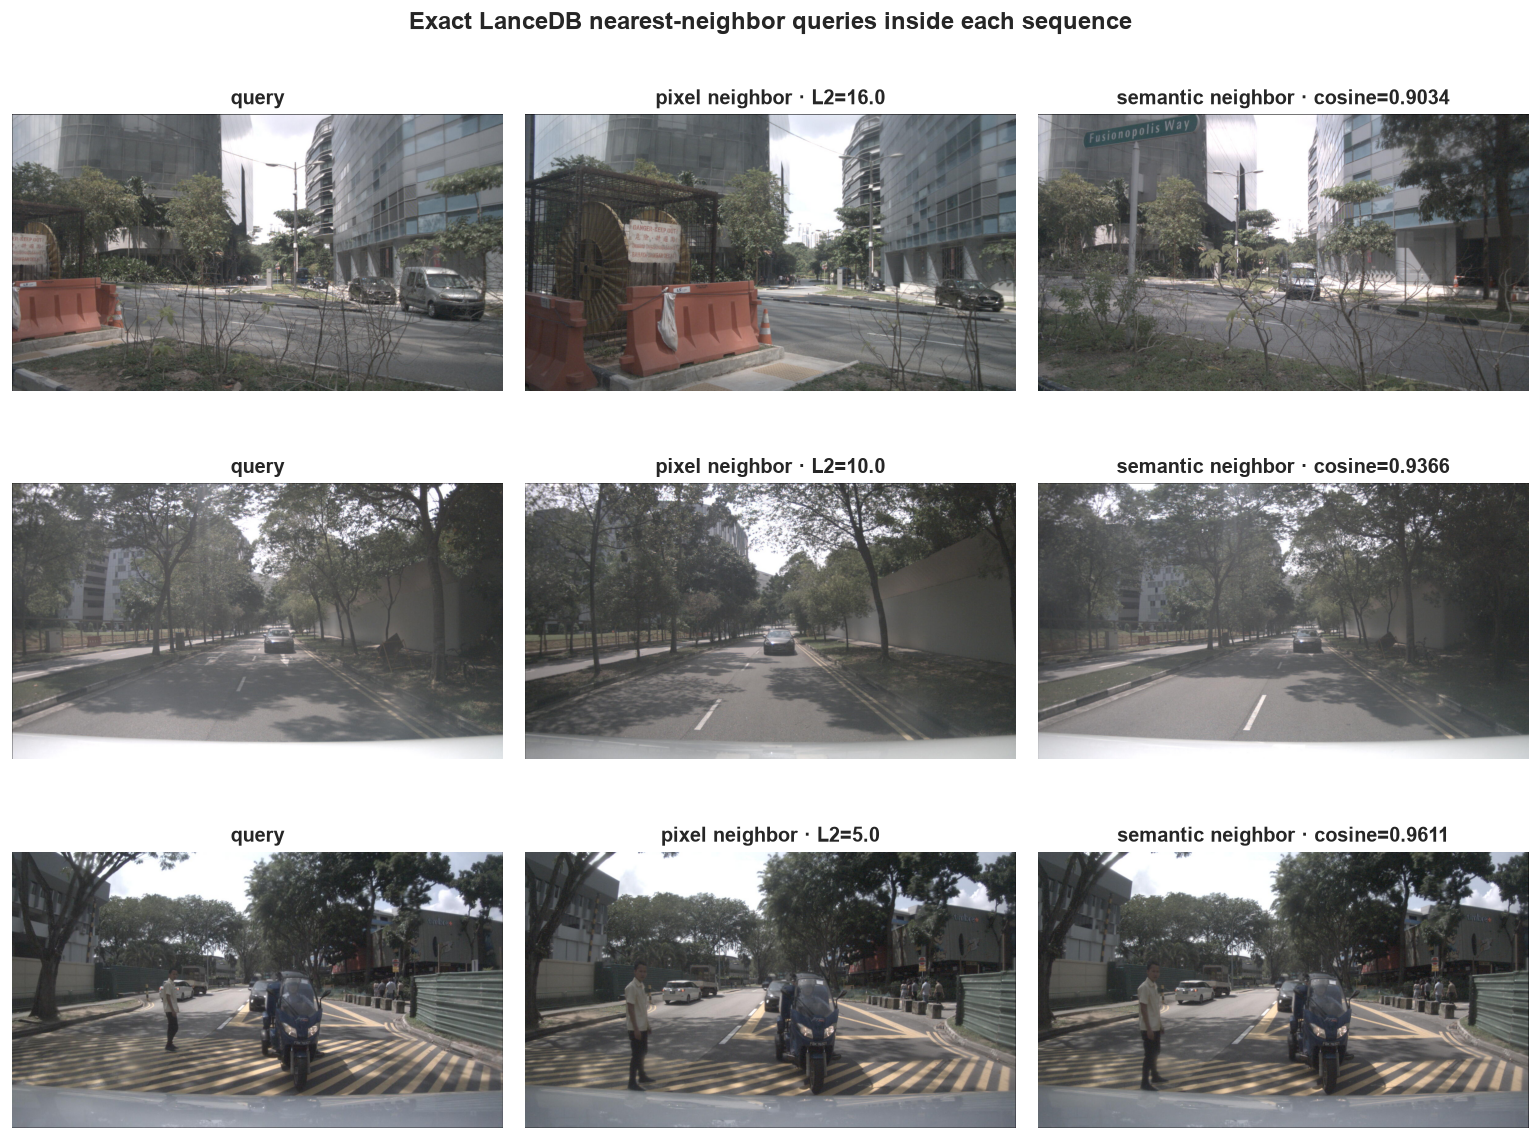

In [10]:
for vector_column, partitions in [("dhash_embedding", 4), ("semantic_embedding", 8)]:
    try:
        table.create_index(metric="L2" if vector_column == "dhash_embedding" else "cosine",
                           vector_column_name=vector_column, index_type="IVF_FLAT",
                           num_partitions=partitions, replace=True)
        print("Indexed", vector_column)
    except Exception as exc:
        print(f"Exact scan retained for {vector_column}: {type(exc).__name__}")

train_anchors = (table.search().where("split = 'train' AND is_key_frame = true").select([
    "frame_id", "sample_id", "image", "labels", "dhash_embedding", "semantic_embedding", "camera_channel"
]).limit(3).to_arrow().to_pylist())

fig, axes = plt.subplots(len(train_anchors), 3, figsize=(13, 3.4 * len(train_anchors)))
for i, anchor in enumerate(train_anchors):
    perceptual = (table.search(anchor["dhash_embedding"], vector_column_name="dhash_embedding")
                  .metric("L2").bypass_vector_index().where(
                      f"split = 'train' AND sample_id = '{anchor['sample_id']}' AND frame_id != '{anchor['frame_id']}'", prefilter=True)
                  .select(["image", "frame_id", "semantic_embedding", "_distance"]).limit(1).to_arrow().to_pylist()[0])
    semantic = (table.search(anchor["semantic_embedding"], vector_column_name="semantic_embedding")
                .metric("cosine").bypass_vector_index().where(
                    f"split = 'train' AND sample_id = '{anchor['sample_id']}' AND frame_id != '{anchor['frame_id']}'", prefilter=True)
                .select(["image", "frame_id", "dhash_embedding", "_distance"]).limit(1).to_arrow().to_pylist()[0])
    items = [(anchor, "query"), (perceptual, f"pixel neighbor · L2={perceptual['_distance']:.1f}"),
             (semantic, f"semantic neighbor · cosine={1-semantic['_distance']:.4f}")]
    for j, (row, title) in enumerate(items):
        axes[i, j].imshow(Image.open(io.BytesIO(row["image"]))); axes[i, j].set_title(title); axes[i, j].axis("off")
plt.suptitle("Exact LanceDB nearest-neighbor queries inside each sequence", fontweight="bold")
plt.tight_layout(); plt.show()

split,test,train,validation
label,,,
barrier,20%,29%,25%
car_present,82%,70%,67%
dense_scene,32%,32%,25%
large_vehicle,61%,40%,42%
pedestrian_present,59%,61%,58%
traffic_cone,20%,30%,34%
two_wheeler,39%,38%,34%


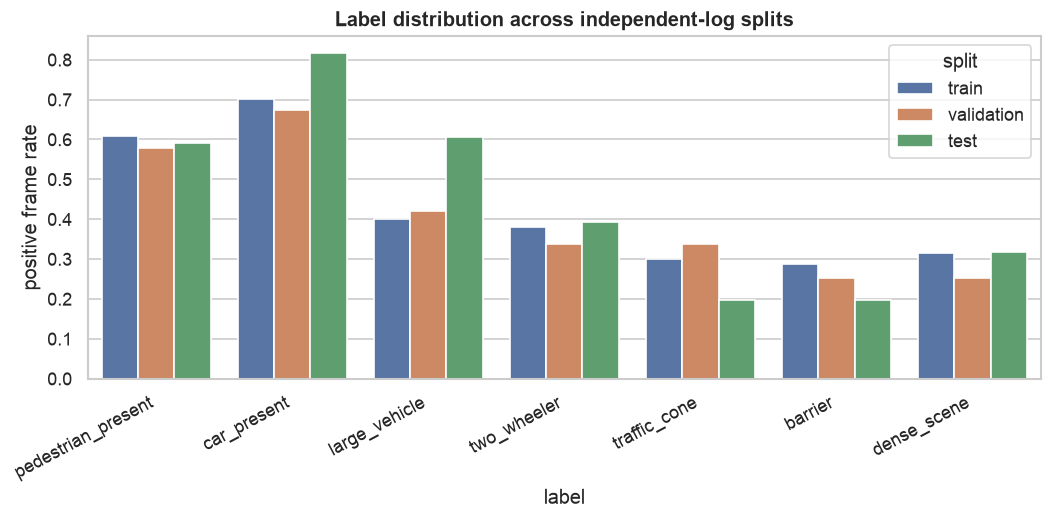

In [11]:
eda = table.search().select(["split", "log_id", "sample_id", "labels", "camera_channel"]).to_arrow().to_pylist()
dist_rows = []
for split in ["train", "validation", "test"]:
    group = [r for r in eda if r["split"] == split]
    for label in LABELS:
        dist_rows.append({"split": split, "label": label,
                          "positive_rate": np.mean([label in r["labels"] for r in group]),
                          "frames": len(group), "logs": len(set(r["log_id"] for r in group))})
dist_df = pd.DataFrame(dist_rows)
display(dist_df.pivot(index="label", columns="split", values="positive_rate").style.format("{:.0%}"))
sns.barplot(data=dist_df, x="label", y="positive_rate", hue="split")
plt.xticks(rotation=28, ha="right"); plt.ylabel("positive frame rate"); plt.title("Label distribution across independent-log splits")
plt.tight_layout(); plt.show()

## 5. Curate with a cross-row UDTF

This is the operation that should not be expressed as a row UDF: rarity, balancing, and deduplication depend on other rows. A UDTF reads the training query, performs the deterministic cross-row decision, and materializes an auditable decision table. The resulting columns are then merged back into the source table.

The local UDTF executor uses Ray. If a restricted environment prevents Ray from starting, the notebook invokes the **same declared UDTF** in-process and clearly records the executor fallback; it does not maintain a second curation algorithm.

In [12]:
CURATION_SCHEMA = pa.schema([
    pa.field("frame_id", pa.string()), pa.field("quality_pass", pa.bool_()),
    pa.field("rarity_score", pa.float32()), pa.field("nearest_hamming", pa.int32()),
    pa.field("nearest_semantic_cosine", pa.float32()), pa.field("duplicate_of", pa.string()),
    pa.field("duplicate_method", pa.string()), pa.field("retained_curated", pa.bool_()),
    pa.field("curation_reason", pa.string()), pa.field("training_eligible", pa.bool_()),
])

def hamming(a, b):
    return int(np.abs(np.asarray(a, dtype=np.float32) - np.asarray(b, dtype=np.float32)).sum())

def cosine(a, b):
    return float(np.dot(np.asarray(a, dtype=np.float32), np.asarray(b, dtype=np.float32)))

@geneva.udtf(
    output_schema=CURATION_SCHEMA,
    input_columns=["frame_id", "sample_id", "time_offset_s", "is_key_frame", "labels",
                   "brightness", "blur_score", "dhash_embedding", "semantic_embedding"],
    version="quality-balance-perceptual-semantic-v3",
)
def curate_training(source):
    records = source.select([
        "frame_id", "sample_id", "time_offset_s", "is_key_frame", "labels",
        "brightness", "blur_score", "dhash_embedding", "semantic_embedding",
    ]).to_arrow().to_pylist()
    records.sort(key=lambda r: (r["sample_id"], r["time_offset_s"]))
    prevalence = {label: np.mean([label in r["labels"] for r in records]) for label in LABELS}
    for r in records:
        positive = [x for x in LABELS if x in r["labels"]]
        negative = [x for x in LABELS if x not in r["labels"]]
        r["rarity_score"] = float(np.mean(
            [1 / np.sqrt(max(prevalence[x], 1e-6)) for x in positive] +
            [0.25 / np.sqrt(max(1 - prevalence[x], 1e-6)) for x in negative]
        ))
    blur_floor = max(15.0, float(np.quantile([r["blur_score"] for r in records], .03)))
    rare_cut = float(np.quantile([r["rarity_score"] for r in records], .80))
    kept_by_sample, signature_counts, output = defaultdict(list), Counter(), []
    for r in records:
        quality = 18 <= r["brightness"] <= 238 and r["blur_score"] >= blur_floor
        signature = tuple(r["labels"])
        candidates = kept_by_sample[r["sample_id"]]
        nearest = max(candidates, key=lambda x: cosine(r["semantic_embedding"], x["semantic_embedding"]), default=None)
        sem = cosine(r["semantic_embedding"], nearest["semantic_embedding"]) if nearest else 0.0
        ham = hamming(r["dhash_embedding"], nearest["dhash_embedding"]) if nearest else 64
        same_labels = nearest is not None and tuple(nearest["labels"]) == signature
        perceptual_duplicate = same_labels and ham <= PERCEPTUAL_HAMMING_THRESHOLD
        semantic_duplicate = same_labels and sem >= SEMANTIC_COSINE_THRESHOLD and ham <= SEMANTIC_DHASH_GUARD
        rare = r["rarity_score"] >= rare_cut
        protected_rare_spacing = rare and (nearest is None or abs(r["time_offset_s"] - nearest["time_offset_s"]) >= 1.0)
        # Keyframes carry direct human annotations. Preserve them even when an image-quality
        # heuristic fires; the sweep rows have propagated labels and are safer to discard.
        if r["is_key_frame"]:
            keep, reason, method = True, "retained_annotated_keyframe", "none"
        elif not quality:
            keep, reason, method = False, "filtered_low_quality", "none"
        elif perceptual_duplicate and not protected_rare_spacing:
            keep, reason, method = False, "dropped_perceptual_duplicate", "dhash"
        elif semantic_duplicate and not protected_rare_spacing:
            keep, reason, method = False, "dropped_semantic_duplicate", "resnet18+high_cosine+dhash_guard"
        elif signature_counts[signature] >= 18 and not rare:
            keep, reason, method = False, "dropped_balance_cap", "none"
        else:
            keep, reason, method = True, "retained_rare" if rare else "retained_balanced", "none"
        if keep:
            kept_by_sample[r["sample_id"]].append(r); signature_counts[signature] += 1
        output.append({
            "frame_id": r["frame_id"], "quality_pass": quality, "rarity_score": r["rarity_score"],
            "nearest_hamming": ham, "nearest_semantic_cosine": sem,
            "duplicate_of": nearest["frame_id"] if nearest else None, "duplicate_method": method,
            "retained_curated": keep, "curation_reason": reason, "training_eligible": True,
        })
    yield pa.RecordBatch.from_pylist(output, schema=CURATION_SCHEMA)

decision_view_name = "training_curation_decisions"
if decision_view_name in db.table_names():
    db.drop_table(decision_view_name)
source_query = table.search().where("split = 'train'")
curation_backend = "LanceDB Feature Engineering UDTF materialized view"
try:
    with db.local_ray_context():
        decision_view = db.create_udtf_view(decision_view_name, source_query, curate_training)
        decision_view.refresh(concurrency=1, _admission_check=False)
    decision_table = decision_view.to_arrow()
except Exception as exc:
    curation_backend = f"same UDTF, in-process executor fallback ({type(exc).__name__})"
    warnings.warn(f"UDTF worker executor unavailable; invoking the same UDTF locally: {exc}")
    decision_table = pa.Table.from_batches(list(curate_training.execute(source_query)), schema=CURATION_SCHEMA)
    decision_view = db.create_table(decision_view_name, decision_table, mode="overwrite")

new_columns = {
    "quality_pass": "cast(null as boolean)", "rarity_score": "cast(null as float)",
    "nearest_hamming": "cast(null as int)", "nearest_semantic_cosine": "cast(null as float)",
    "duplicate_of": "cast(null as string)", "duplicate_method": "cast(null as string)",
    "retained_curated": "cast(null as boolean)", "curation_reason": "cast(null as string)",
    "training_eligible": "cast(null as boolean)",
}
for name, expr in new_columns.items():
    if name not in table.schema.names: table.add_columns({name: expr})

held_out = table.search().where("split != 'train'").select(["frame_id"]).to_arrow().to_pylist()
held_out_updates = [{"frame_id": r["frame_id"], "retained_curated": False,
                     "curation_reason": "held_out_independent_log", "training_eligible": False,
                     "duplicate_method": "none"} for r in held_out]
table.merge_insert("frame_id").when_matched_update_all().execute(decision_table)
table.merge_insert("frame_id").when_matched_update_all().execute(pa.Table.from_pylist(held_out_updates))

raw_count = table.count_rows("split = 'train'")
curated_count = table.count_rows("split = 'train' AND retained_curated = true")
reason_counts = (table.search().where("split = 'train'").select(["curation_reason"]).to_arrow().to_pandas()["curation_reason"].value_counts())
print("Curation backend:", curation_backend)
display(pd.DataFrame({"dataset": ["raw_train", "curated_train"], "examples": [raw_count, curated_count],
                      "fraction_of_raw": [1.0, curated_count / raw_count]}).style.format({"fraction_of_raw": "{:.1%}"}))
display(reason_counts.rename_axis("reason").to_frame("frames"))
display(table.search().where("split = 'train'").select([
    "frame_id", "is_key_frame", "nearest_hamming", "nearest_semantic_cosine",
    "duplicate_method", "retained_curated", "curation_reason"
]).limit(14).to_arrow().to_pandas())

Initializing Ray cluster. This could take a few minutes, especially if there are lots of dependencies to install.
2026-08-25 08:59:31,770	INFO worker.py:2015 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
(run_ray_refresh_remote pid=95539) 2026-08-25 08:59:34,854 INFO geneva.db: Deferring system namespace creation for directory namespace: ['__system']
(run_ray_refresh_remote pid=95539) 2026-08-25 08:59:34,855 INFO geneva.db: using namespace connection: self._namespace_connection=<lancedb.namespace.LanceNamespaceDBConnection object at 0x11d85bef0>
(run_ray_refresh_remote pid=95539) 2026-08-25 08:59:34,860 INFO geneva.utils.schema: opened system table name=geneva_jobs namespace=['__system'] uri=/Users/taylor/Documents/GitHub/lancedb-mcap-demo/data/lancedb-v2/30dea526___system$geneva_jobs
(run_ray_refresh_remote pid=95539) 2026-08-25 08:59:34,861 INFO geneva.runners.ray.pipeline: run_ray_refresh_remote: starting job_id=3fcf1130026543908c4d9c8ed1f1001f table=

Curation backend: LanceDB Feature Engineering UDTF materialized view


,dataset,examples,fraction_of_raw
0,raw_train,187,100.0%
1,curated_train,161,86.1%


,frames
reason,
retained_balanced,106
retained_annotated_keyframe,28
retained_rare,27
dropped_perceptual_duplicate,20
filtered_low_quality,5
dropped_semantic_duplicate,1


,frame_id,is_key_frame,nearest_hamming,nearest_semantic_cosine,duplicate_method,retained_curated,curation_reason
0,09acd654cb514bdeab8e3afedad74fca-1535352273370...,False,64,0.000000,none,True,retained_rare
1,09acd654cb514bdeab8e3afedad74fca-1535352273870...,False,13,0.922626,none,True,retained_rare
2,09acd654cb514bdeab8e3afedad74fca-1535352274370...,False,9,0.882578,none,True,retained_rare
3,09acd654cb514bdeab8e3afedad74fca-1535352274870...,True,17,0.903396,none,True,retained_annotated_keyframe
4,09acd654cb514bdeab8e3afedad74fca-1535352275370...,False,16,0.884501,none,True,retained_rare
5,09acd654cb514bdeab8e3afedad74fca-1535352275870...,False,29,0.816605,none,True,retained_rare
6,09acd654cb514bdeab8e3afedad74fca-1535352276370...,False,17,0.888713,none,True,retained_rare
7,0b38985d779b4fcd94cf846006c93bed-1535514186037...,False,64,0.000000,none,True,retained_balanced
8,0b38985d779b4fcd94cf846006c93bed-1535514186537...,False,11,0.924789,none,True,retained_balanced
9,0b38985d779b4fcd94cf846006c93bed-1535514187037...,False,9,0.930307,none,True,retained_balanced


dataset,curated_train,raw_train
label,,
barrier,29%,29%
car_present,70%,70%
dense_scene,33%,32%
large_vehicle,39%,40%
pedestrian_present,64%,61%
traffic_cone,32%,30%
two_wheeler,42%,38%


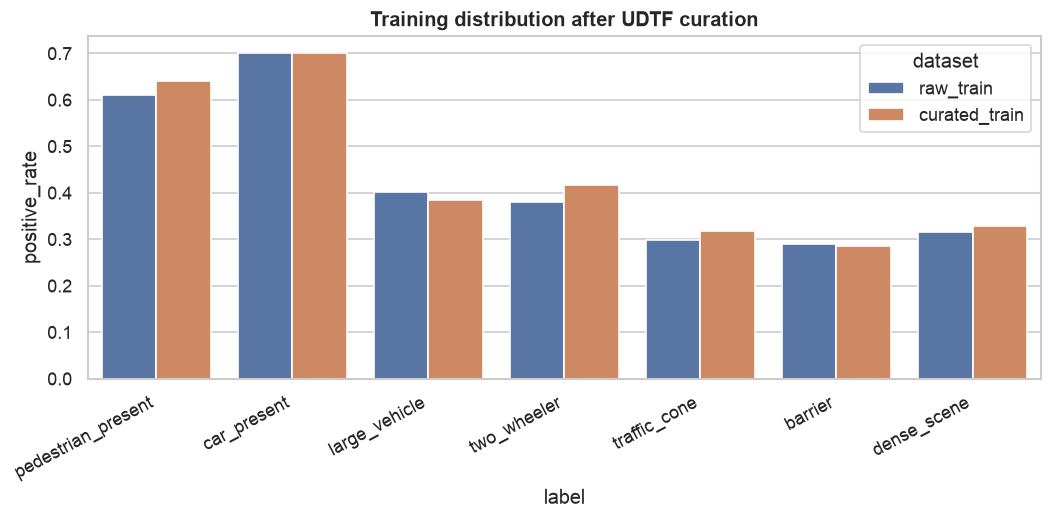

In [13]:
cur_dist = []
for dataset_name, predicate in [("raw_train", "split = 'train'"),
                                 ("curated_train", "split = 'train' AND retained_curated = true")]:
    records = table.search().where(predicate).select(["labels"]).to_arrow().to_pylist()
    for label in LABELS:
        cur_dist.append({"dataset": dataset_name, "label": label,
                         "positive_rate": np.mean([label in r["labels"] for r in records]), "n": len(records)})
cur_dist = pd.DataFrame(cur_dist)
display(cur_dist.pivot(index="label", columns="dataset", values="positive_rate").style.format("{:.0%}"))
sns.barplot(data=cur_dist, x="label", y="positive_rate", hue="dataset")
plt.xticks(rotation=28, ha="right"); plt.title("Training distribution after UDTF curation")
plt.tight_layout(); plt.show()

## 6. Full-model training directly from LanceDB

This version performs **full fine-tuning**, not LoRA: every language, connector, and vision parameter is trainable. The model is intentionally small—SmolVLM-256M in bfloat16—so two one-epoch runs remain practical on Apple Silicon or an NVIDIA GPU. The code verifies that the vision tower is trainable and reports the trainable parameter count.

The dataset keeps only frame IDs in memory; each `__getitem__` performs a LanceDB point query for `model_image` and `label_text`, decodes the bytes, and passes the image to the processor. `num_workers=0` is intentional because the in-process LanceDB table handle stays in the training process.

Raw and curated conditions use identical learning rate, model initialization, sample-order seed, and **optimizer-step budget**. The curated set is smaller, so its deterministic sampler starts a second shuffled pass to reach the same number of updates as raw. This isolates data selection from training compute; the comparison no longer handicaps curation by giving it fewer learning opportunities.

In [14]:
from transformers import AutoModelForImageTextToText, AutoProcessor

training_config = {
    "model": MODEL_ID, "full_finetune": True, "train_vision": True,
    "optimizer_step_policy": "equal_to_raw_train_rows", "optimizer_steps": raw_count,
    "learning_rate": LEARNING_RATE, "batch_size": 1,
    "model_image_size": MODEL_IMAGE_SIZE, "question": QUESTION,
    "seed": SEED, "source_sha256": SOURCE_SHA256,
    "curation": {
        "semantic_cosine": SEMANTIC_COSINE_THRESHOLD,
        "semantic_dhash_guard": SEMANTIC_DHASH_GUARD,
        "perceptual_hamming": PERCEPTUAL_HAMMING_THRESHOLD,
    },
}
experiment_fingerprint = hashlib.sha256(json.dumps(training_config, sort_keys=True).encode()).hexdigest()
print("Experiment fingerprint:", experiment_fingerprint[:16])

def load_processor(path=MODEL_ID):
    processor = AutoProcessor.from_pretrained(path)
    # The model was trained at 512px. Disabling tiling reduces one driving frame from many crops to one image.
    processor.image_processor.do_image_splitting = False
    processor.image_processor.size = {"longest_edge": 512}
    processor.image_processor.max_image_size = {"longest_edge": 512}
    return processor

def load_model(path=MODEL_ID):
    model = AutoModelForImageTextToText.from_pretrained(path, dtype=MODEL_DTYPE).to(DEVICE)
    model.config.pad_token_id = 2
    model.generation_config.pad_token_id = 2
    return model

class LanceVisionDataset:
    def __init__(self, table, predicate, processor):
        self.table, self.processor = table, processor
        self.frame_ids = sorted(r["frame_id"] for r in table.search().where(predicate).select(["frame_id"]).to_arrow().to_pylist())
    def __len__(self): return len(self.frame_ids)
    def record(self, index):
        frame_id = self.frame_ids[index]
        result = (self.table.search().where(f"frame_id = '{frame_id}'")
                  .select(["frame_id", "model_image", "label_text", "labels"]).limit(1).to_arrow().to_pylist())
        if len(result) != 1: raise KeyError(frame_id)
        return result[0]
    def __getitem__(self, index):
        row = self.record(index)
        image = Image.open(io.BytesIO(row["model_image"])).convert("RGB")
        user = {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": QUESTION}]}
        assistant = {"role": "assistant", "content": [{"type": "text", "text": row["label_text"]}]}
        encoded = self.processor.apply_chat_template([user, assistant], add_generation_prompt=False,
                                                     tokenize=True, return_dict=True, return_tensors="pt")
        prompt = self.processor.apply_chat_template([user], add_generation_prompt=True,
                                                    tokenize=True, return_dict=True, return_tensors="pt")
        labels = encoded["input_ids"].clone()
        labels[:, :prompt["input_ids"].shape[1]] = -100
        encoded["labels"] = labels
        return {k: v.to(DEVICE) for k, v in encoded.items() if torch.is_tensor(v)}

def mean_validation_loss(model, processor):
    dataset = LanceVisionDataset(table, "split = 'validation'", processor)
    positions = np.linspace(0, len(dataset) - 1, min(VALIDATION_LOSS_EXAMPLES, len(dataset)), dtype=int)
    losses = []
    model.eval()
    with torch.inference_mode():
        for i in positions:
            losses.append(float(model(**dataset[int(i)]).loss.detach().cpu()))
    model.train()
    return float(np.mean(losses))

def train_full_model(name, predicate):
    if DEVICE.type == "cpu" and not ALLOW_CPU_FULL_TRAINING:
        raise RuntimeError("Full training on CPU is disabled by default. Use Apple Metal/NVIDIA CUDA, or set ALLOW_CPU_FULL_TRAINING=1 before starting Jupyter.")
    checkpoint = ARTIFACTS / "models" / f"{name}-{experiment_fingerprint[:12]}"
    stats_path = checkpoint / "training_stats.json"
    if (checkpoint / "model.safetensors").exists() and stats_path.exists():
        stats = json.loads(stats_path.read_text())
        if stats.get("fingerprint") == experiment_fingerprint:
            print(f"Cache hit: {name} full model"); return stats
    if checkpoint.exists(): shutil.rmtree(checkpoint)
    checkpoint.mkdir(parents=True)
    processor, model = load_processor(), load_model()
    for parameter in model.parameters(): parameter.requires_grad_(True)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    vision_trainable = all(p.requires_grad for p in model.model.vision_model.parameters())
    if trainable_params != total_params or not vision_trainable:
        raise RuntimeError("Full fine-tuning invariant failed: not every parameter, including vision, is trainable")
    model.config.use_cache = False
    dataset = LanceVisionDataset(table, predicate, processor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    history, started = [], time.perf_counter()
    model.train()
    optimizer_steps = raw_count
    completed, cycle = 0, 0
    progress = tqdm(total=optimizer_steps, desc=f"Full-train {name}")
    while completed < optimizer_steps:
        generator = torch.Generator().manual_seed(SEED + cycle)
        order = torch.randperm(len(dataset), generator=generator).tolist()
        for index in order[:optimizer_steps - completed]:
            optimizer.zero_grad(set_to_none=True)
            loss = model(**dataset[index]).loss
            if not torch.isfinite(loss): raise RuntimeError(f"Non-finite loss at step {completed + 1}: {loss}")
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
            value = float(loss.detach().cpu()); history.append(value); completed += 1; progress.update(1)
            if completed % 10 == 0: progress.set_postfix(loss=f"{np.mean(history[-10:]):.3f}")
        cycle += 1
    progress.close()
    if DEVICE.type == "mps": torch.mps.synchronize()
    elif DEVICE.type == "cuda": torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    validation_loss = mean_validation_loss(model, processor)
    model.config.use_cache = True
    model.save_pretrained(checkpoint, safe_serialization=True)
    processor.save_pretrained(checkpoint)
    stats = {
        "condition": name, "fingerprint": experiment_fingerprint, "checkpoint": str(checkpoint),
        "examples": len(dataset), "examples_seen": optimizer_steps,
        "effective_epochs": optimizer_steps / len(dataset), "optimizer_steps": optimizer_steps,
        "seconds": elapsed, "examples_per_second": len(dataset) / elapsed,
        "final_train_loss_10_step_mean": float(np.mean(history[-10:])), "validation_loss": validation_loss,
        "total_parameters": total_params, "trainable_parameters": trainable_params,
        "vision_trainable": vision_trainable, "full_finetune": True,
    }
    stats_path.write_text(json.dumps(stats, indent=2))
    del model, processor, optimizer; gc.collect()
    if DEVICE.type == "mps": torch.mps.empty_cache()
    elif DEVICE.type == "cuda": torch.cuda.empty_cache()
    return stats

raw_stats = train_full_model("raw", "split = 'train'")
curated_stats = train_full_model("curated", "split = 'train' AND retained_curated = true")
training_stats = pd.DataFrame([raw_stats, curated_stats])
display(training_stats[["condition", "examples", "examples_seen", "effective_epochs", "optimizer_steps", "seconds", "validation_loss",
                        "trainable_parameters", "vision_trainable", "full_finetune"]].style.format({
    "seconds": "{:.1f}", "effective_epochs": "{:.2f}", "validation_loss": "{:.3f}", "trainable_parameters": "{:,}"}))

Experiment fingerprint: f59fdba140bc1223
Cache hit: raw full model
Cache hit: curated full model


,condition,examples,examples_seen,effective_epochs,optimizer_steps,seconds,validation_loss,trainable_parameters,vision_trainable,full_finetune
0,raw,187,187,1.00,187,96.2,0.874,"256,484,928",True,True
1,curated,161,187,1.16,187,95.5,0.910,"256,484,928",True,True


## 7. Strict held-out evaluation

All conditions are evaluated on the same complete held-out driving logs. Generation is greedy. The parser calls `json.loads` on the entire response and accepts only a unique list of declared label strings. Prose, Markdown fences, unknown labels, duplicates, or malformed JSON are invalid and score as an empty prediction; format compliance is reported separately.

Macro F1 is primary, with micro F1, exact-set accuracy, per-class precision/recall/F1, and JSON compliance. Qualitative examples are fixed by position—first, one-third, two-thirds, and last—not selected by correctness.

In [15]:
EVAL_DIR = ARTIFACTS / "eval"; EVAL_DIR.mkdir(parents=True, exist_ok=True)
test_ids = sorted(r["frame_id"] for r in table.search().where("split = 'test'").select(["frame_id"]).to_arrow().to_pylist())

def strict_parse_prediction(text: str):
    try:
        value = json.loads(text.strip())
    except (json.JSONDecodeError, TypeError):
        return [], False, "malformed_json"
    if not isinstance(value, list) or not all(isinstance(x, str) for x in value):
        return [], False, "not_string_array"
    if len(value) != len(set(value)):
        return [], False, "duplicate_labels"
    unknown = [x for x in value if x not in LABELS]
    if unknown:
        return [], False, "unknown_labels"
    return [x for x in LABELS if x in value], True, "valid"

def evaluate_condition(condition, checkpoint=None):
    checkpoint_fingerprint = "vanilla" if checkpoint is None else hashlib.sha256((experiment_fingerprint + condition).encode()).hexdigest()
    cache = EVAL_DIR / f"{condition}-{checkpoint_fingerprint[:12]}.jsonl"
    if cache.exists():
        cached = [json.loads(line) for line in open(cache)]
        if len(cached) == len(test_ids) and [x["frame_id"] for x in cached] == test_ids:
            print(f"Cache hit: {condition} predictions"); return cached
    processor, model = load_processor(checkpoint or MODEL_ID), load_model(checkpoint or MODEL_ID)
    model.eval(); outputs = []
    with open(cache, "w") as f, torch.inference_mode():
        for frame_id in tqdm(test_ids, desc=f"Evaluate {condition}"):
            row = (table.search().where(f"frame_id = '{frame_id}'")
                   .select(["frame_id", "model_image", "labels", "log_id", "camera_channel"])
                   .limit(1).to_arrow().to_pylist()[0])
            image = Image.open(io.BytesIO(row["model_image"])).convert("RGB")
            messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": QUESTION}]}]
            inputs = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True,
                                                   return_dict=True, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items() if torch.is_tensor(v)}
            generated = model.generate(**inputs, max_new_tokens=48, do_sample=False)
            text = processor.decode(generated[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
            prediction, valid, format_error = strict_parse_prediction(text)
            item = {"frame_id": frame_id, "truth": row["labels"], "prediction": prediction,
                    "valid_json": valid, "format_error": format_error, "raw_text": text,
                    "log_id": row["log_id"], "camera_channel": row["camera_channel"]}
            outputs.append(item); f.write(json.dumps(item) + "\n"); f.flush()
    del model, processor; gc.collect()
    if DEVICE.type == "mps": torch.mps.empty_cache()
    elif DEVICE.type == "cuda": torch.cuda.empty_cache()
    return outputs

prediction_sets = {
    "vanilla": evaluate_condition("vanilla"),
    "raw_full_trained": evaluate_condition("raw_full_trained", raw_stats["checkpoint"]),
    "curated_full_trained": evaluate_condition("curated_full_trained", curated_stats["checkpoint"]),
}

Cache hit: vanilla predictions
Cache hit: raw_full_trained predictions
Cache hit: curated_full_trained predictions


,condition,macro_f1,micro_f1,exact_set_accuracy,json_compliance,training_examples,optimizer_steps,training_seconds
0,curated_full_trained,0.563,0.596,0.000,87.9%,161,187,95.5
1,raw_full_trained,0.537,0.565,0.000,75.8%,187,187,96.2
2,vanilla,0.000,0.000,0.000,0.0%,0,0,0.0


condition,curated_full_trained,raw_full_trained,vanilla
label,,,
barrier,0.358,0.340,0.000
car_present,0.821,0.731,0.000
dense_scene,0.400,0.328,0.000
large_vehicle,0.617,0.475,0.000
pedestrian_present,0.792,0.690,0.000
traffic_cone,0.328,0.491,0.000
two_wheeler,0.627,0.704,0.000


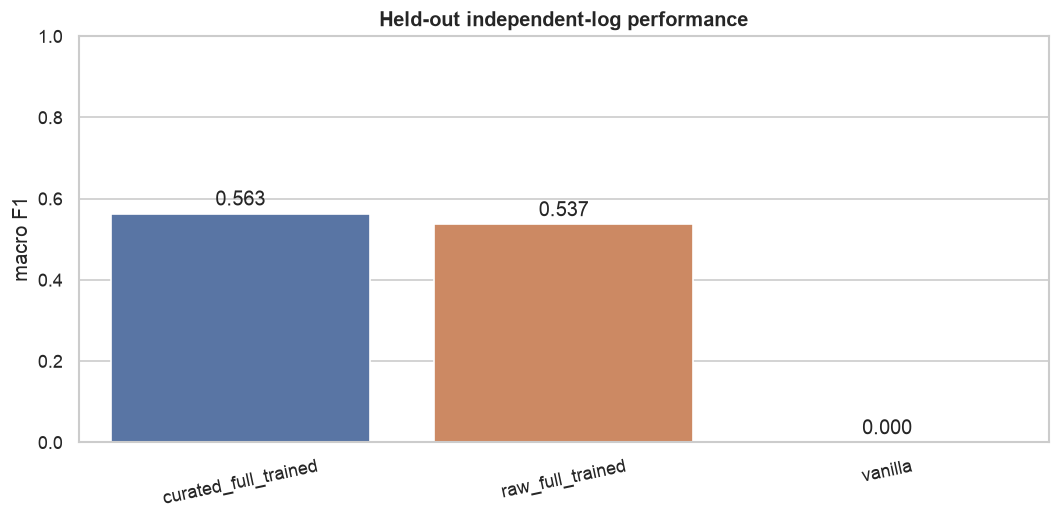

In [16]:
def binary_matrix(label_lists):
    return np.asarray([[label in labels for label in LABELS] for labels in label_lists], dtype=int)

metric_rows, per_class_rows = [], []
for condition, outputs in prediction_sets.items():
    y_true = binary_matrix([x["truth"] for x in outputs])
    y_pred = binary_matrix([x["prediction"] for x in outputs])
    training = None if condition == "vanilla" else raw_stats if condition.startswith("raw") else curated_stats
    metric_rows.append({
        "condition": condition,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "exact_set_accuracy": np.mean(np.all(y_true == y_pred, axis=1)),
        "json_compliance": np.mean([x["valid_json"] for x in outputs]),
        "training_examples": 0 if training is None else training["examples"],
        "optimizer_steps": 0 if training is None else training["optimizer_steps"],
        "training_seconds": 0 if training is None else training["seconds"],
    })
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    for label, p, r, score, n in zip(LABELS, precision, recall, f1, support):
        per_class_rows.append({"condition": condition, "label": label, "precision": p, "recall": r,
                               "f1": score, "positive_test_frames": n})

results = pd.DataFrame(metric_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
per_class = pd.DataFrame(per_class_rows)
display(results.style.format({"macro_f1": "{:.3f}", "micro_f1": "{:.3f}", "exact_set_accuracy": "{:.3f}",
                              "json_compliance": "{:.1%}", "training_seconds": "{:.1f}"}))
display(per_class.pivot(index="label", columns="condition", values="f1").style.format("{:.3f}"))

sns.barplot(data=results, x="condition", y="macro_f1", hue="condition", legend=False)
plt.ylim(0, 1); plt.ylabel("macro F1"); plt.xlabel(""); plt.title("Held-out independent-log performance")
for i, value in enumerate(results["macro_f1"]): plt.text(i, value + .02, f"{value:.3f}", ha="center")
plt.xticks(rotation=12); plt.tight_layout(); plt.show()

### Observed result

**The curated point estimate improved macro F1 by +0.026 with 14% fewer unique frames at the same 187-update budget. Its log-cluster bootstrap 95% interval is [-0.031, +0.091] (positive in 80.4% of resamples).**

Because the interval includes zero, this run shows an observed advantage—not proof that curation will win generally. The correct next step is a larger official split and multiple training seeds, not test-set threshold tuning.

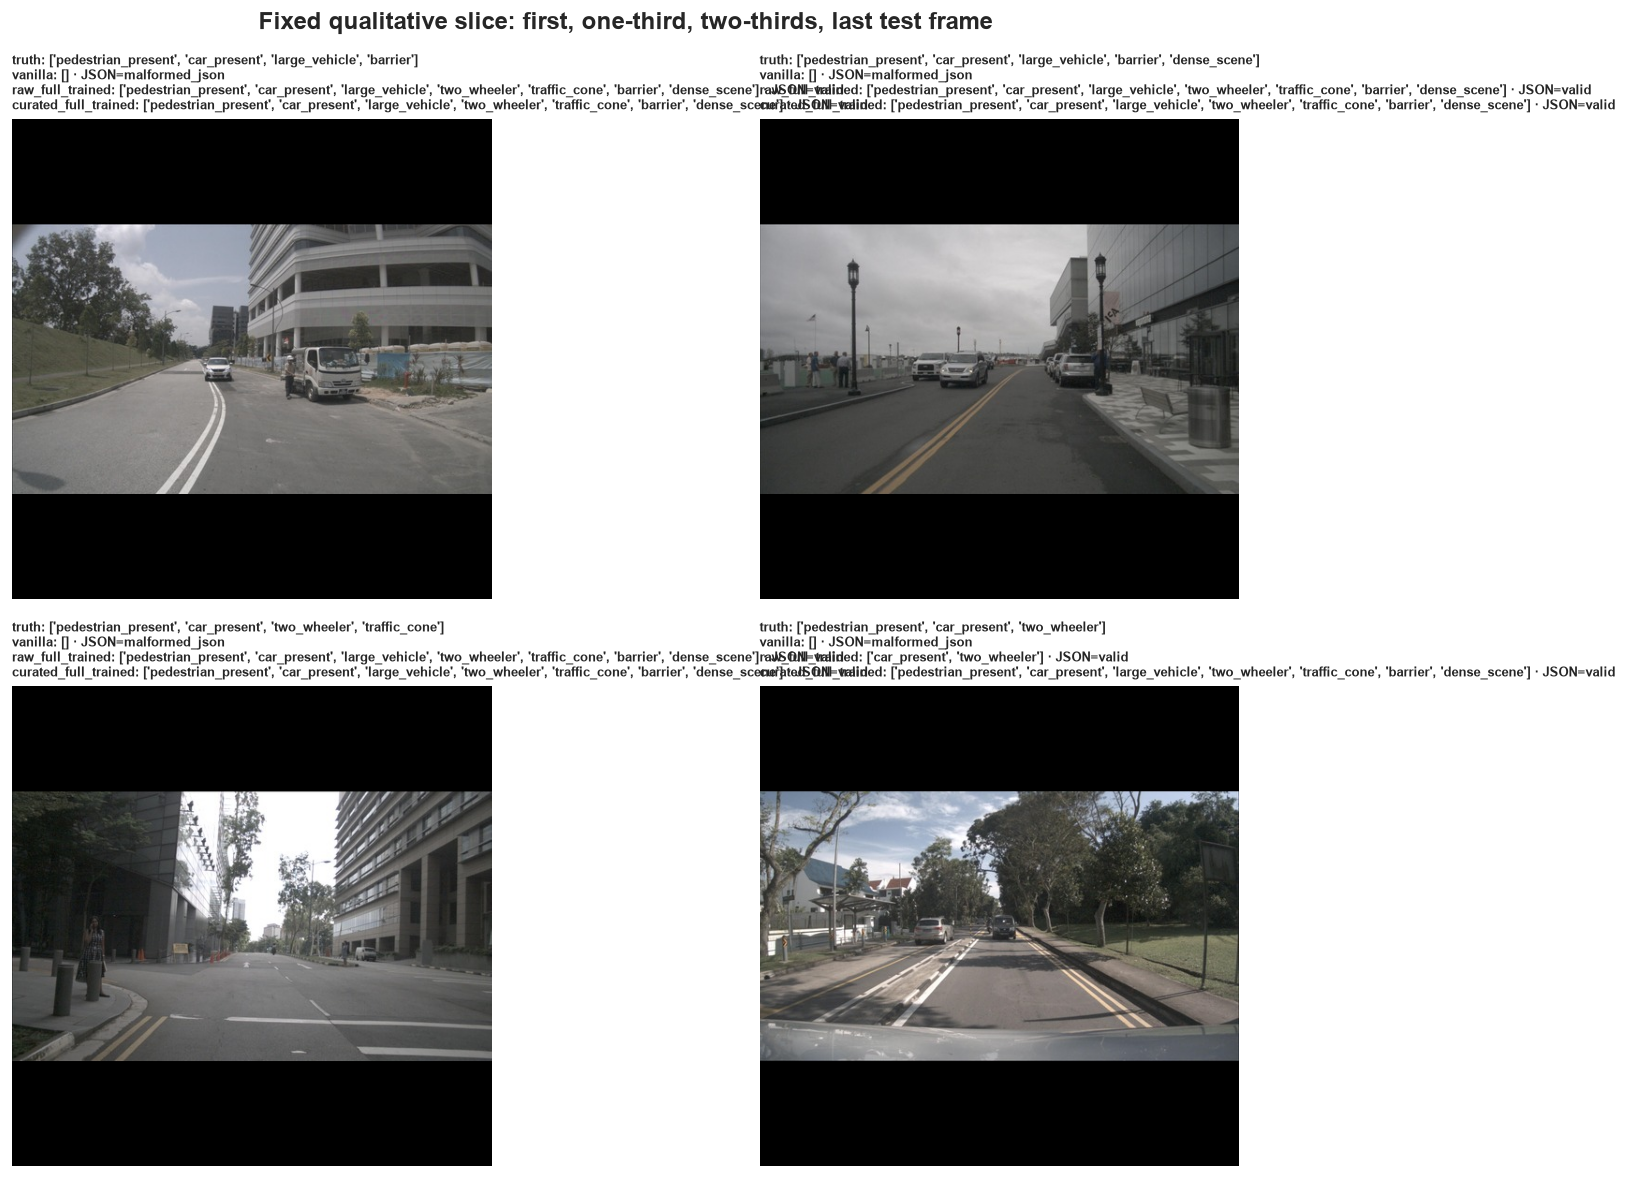

In [17]:
raw_score = float(results.set_index("condition").loc["raw_full_trained", "macro_f1"])
curated_score = float(results.set_index("condition").loc["curated_full_trained", "macro_f1"])
delta, efficiency = curated_score - raw_score, 1 - curated_stats["examples"] / raw_stats["examples"]

# Paired cluster bootstrap: resample whole held-out logs, not correlated frames.
raw_outputs, curated_outputs = prediction_sets["raw_full_trained"], prediction_sets["curated_full_trained"]
test_logs = sorted(set(x["log_id"] for x in raw_outputs))
indices_by_log = {log: [i for i, x in enumerate(raw_outputs) if x["log_id"] == log] for log in test_logs}
rng, bootstrap_deltas = np.random.default_rng(SEED), []
for _ in range(5_000):
    sampled_logs = rng.choice(test_logs, size=len(test_logs), replace=True)
    indices = np.concatenate([indices_by_log[log] for log in sampled_logs])
    y_true = binary_matrix([raw_outputs[i]["truth"] for i in indices])
    y_raw = binary_matrix([raw_outputs[i]["prediction"] for i in indices])
    y_curated = binary_matrix([curated_outputs[i]["prediction"] for i in indices])
    bootstrap_deltas.append(
        f1_score(y_true, y_curated, average="macro", zero_division=0)
        - f1_score(y_true, y_raw, average="macro", zero_division=0)
    )
ci_low, ci_high = np.quantile(bootstrap_deltas, [.025, .975])
win_probability = np.mean(np.asarray(bootstrap_deltas) > 0)

conclusion = (
    f"The curated point estimate improved macro F1 by {delta:+.3f} with {efficiency:.0%} fewer unique "
    f"frames at the same {raw_stats['optimizer_steps']}-update budget. Its log-cluster bootstrap 95% interval "
    f"is [{ci_low:+.3f}, {ci_high:+.3f}] (positive in {win_probability:.1%} of resamples)."
)
display(Markdown(f"### Observed result\n\n**{conclusion}**\n\nBecause the interval includes zero, this run shows an observed advantage—not proof that curation will win generally. The correct next step is a larger official split and multiple training seeds, not test-set threshold tuning."))

positions = sorted(set([0, len(test_ids)//3, 2*len(test_ids)//3, len(test_ids)-1]))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, index in zip(np.asarray(axes).reshape(-1), positions):
    frame_id = test_ids[index]
    row = table.search().where(f"frame_id = '{frame_id}'").select(["model_image"]).limit(1).to_arrow().to_pylist()[0]
    ax.imshow(Image.open(io.BytesIO(row["model_image"]))); ax.axis("off")
    lines = [f"truth: {prediction_sets['vanilla'][index]['truth']}"]
    for condition in ["vanilla", "raw_full_trained", "curated_full_trained"]:
        item = prediction_sets[condition][index]
        lines.append(f"{condition}: {item['prediction']} · JSON={'valid' if item['valid_json'] else item['format_error']}")
    ax.set_title("\n".join(lines), loc="left", fontsize=8)
plt.suptitle("Fixed qualitative slice: first, one-third, two-thirds, last test frame", fontweight="bold")
plt.tight_layout(); plt.show()

## 8. What is—and is not—demonstrated

| Layer | Exercised here | Boundary |
|---|---|---|
| **MCAP** | 50 compact, timestamped camera/annotation logs normalized from the public nuImages mini archive | The upstream release is an image dataset; the notebook performs the MCAP normalization explicitly |
| **Lance** | Source JPEG, model-ready JPEG, typed metadata, labels, features, and curation audit columns | Additional image representations consume storage but eliminate a loose-file training cache |
| **LanceDB OSS** | Local table creation, point reads during training, SQL-style filters, merges, and exact/vector search | The trainer is PyTorch; LanceDB supplies records but does not perform gradient updates |
| **LanceDB Feature Engineering** | Versioned row UDF backfills plus a real cross-row UDTF materialized view for curation | The UDTF API is beta; restricted runtimes may use the same UDTF through the documented in-process executor fallback |
| **Full VLM training** | All 256M parameters, including the vision tower, update on Metal/CUDA/CPU | This is scene tagging, not detection, tracking, sensor fusion, or an autonomous-driving policy |
| **LanceDB Enterprise** | **Not used** | At larger scale it can add managed distributed execution/serving, independent compute and storage, caching, indexing, compaction, concurrency, and object-store operation |

The 44-log split is a substantial correction over one short scene, but nuImages mini remains small. Sweep labels are inherited from a keyframe within ±1.5 seconds, which introduces controlled label noise. The reported paired bootstrap resamples whole test logs and its interval still spans zero. A benchmark run should use the full official train/validation releases, evaluate only directly annotated frames or temporal annotations, quantify uncertainty across multiple training seeds, and tune curation thresholds on validation data only.

All six camera positions are represented, but each record is still a single image. LiDAR, radar, ego motion, calibration-aware fusion, multi-view context, and temporal inputs are deliberately out of scope and should not be inferred from the results.

## 9. Run manifest and cache integrity

The manifest binds the result to source bytes, feature and curation executors, model/training configuration, split groups, exact package versions, checkpoints, and metrics. Training and prediction cache paths contain the experiment fingerprint; changing a material input creates a new cache instead of silently reusing stale artifacts.

In [18]:
import importlib.metadata as metadata

manifest = {
    "source": {"url": SOURCE_URL, "sha256": SOURCE_SHA256, "bytes": SOURCE_ARCHIVE.stat().st_size,
               "annotated_samples": len(samples), "independent_logs": len(set(groups))},
    "mcap": {"directory": str(MCAP_DIR), "files": len(list(MCAP_DIR.glob("*.mcap"))),
             "conversion_fingerprint": conversion_fingerprint},
    "table": {"path": str(DB_DIR), "name": TABLE_NAME, "version": table.version, "rows": table.count_rows()},
    "splits": {split: {"rows": table.count_rows(f"split = '{split}'"),
                        "logs": len(set(r["log_id"] for r in table.search().where(f"split = '{split}'").select(["log_id"]).to_arrow().to_pylist()))}
               for split in ["train", "validation", "test"]},
    "feature_backend": feature_backend, "curation_backend": curation_backend,
    "curated_train_rows": curated_count, "experiment_fingerprint": experiment_fingerprint,
    "training_config": training_config, "hardware": hardware,
    "packages": {name: metadata.version(name) for name in ["lancedb", "geneva", "mcap", "pyarrow", "torch", "torchvision", "transformers"]},
    "training": [raw_stats, curated_stats], "results": results.to_dict(orient="records"),
}
manifest_path = ARTIFACTS / f"run_manifest-{experiment_fingerprint[:12]}.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
display(pd.DataFrame(manifest["results"]).style.format({"macro_f1": "{:.3f}", "micro_f1": "{:.3f}",
                                                        "exact_set_accuracy": "{:.3f}", "json_compliance": "{:.1%}"}))
print("Manifest:", manifest_path)
print("Canonical Lance table:", DB_DIR / f"{TABLE_NAME}.lance")

,condition,macro_f1,micro_f1,exact_set_accuracy,json_compliance,training_examples,optimizer_steps,training_seconds
0,curated_full_trained,0.563,0.596,0.000,87.9%,161,187,95.482148
1,raw_full_trained,0.537,0.565,0.000,75.8%,187,187,96.214925
2,vanilla,0.000,0.000,0.000,0.0%,0,0,0.000000


Manifest: /Users/taylor/Documents/GitHub/lancedb-mcap-demo/artifacts-v2/run_manifest-f59fdba140bc.json
Canonical Lance table: /Users/taylor/Documents/GitHub/lancedb-mcap-demo/data/lancedb-v2/nuimages_multicamera.lance
